# Model ANN (LSTM) & Hybrid ARIMA-LSTM — Forecasting Harga Saham Batubara IDX

Notebook ini membangun:
1. **Model LSTM murni** — menangkap pola non-linear dari harga saham
2. **Hybrid ARIMA-LSTM** — menggabungkan prediksi linear ARIMA dengan prediksi
   residual LSTM: `ŷ_hybrid = ŷ_ARIMA + ŷ_LSTM(ε_ARIMA)`

Tahapan:
1. Load data + residual ARIMA dari Notebook 02
2. Feature engineering: windowed sequences
3. Arsitektur LSTM (dua layer + Dropout)
4. Training dengan Early Stopping & Learning Rate Scheduler
5. Evaluasi: MAE, RMSE, MAPE, R²
6. Perbandingan ARIMA vs LSTM vs Hybrid
7. Forecast panjang 2025–2045
8. Semua figure publication-ready untuk jurnal JUTIF


## 1. Import Library

In [14]:
import sys
print(sys.executable)

c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Scripts\python.exe


In [15]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # suppress TensorFlow logs

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Reproducibility
SEED = 2024
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.21.0
GPU available      : False


In [16]:
%matplotlib inline

## 2. Konfigurasi Visualisasi (konsisten dengan Notebook 01 & 02)

In [17]:
FONT = "DejaVu Serif"

plt.rcParams.update({
    "font.family":        FONT,
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
})

C = {
    "navy":   "#1B3A6B",
    "blue":   "#2471A3",
    "red":    "#C0392B",
    "orange": "#D35400",
    "green":  "#1E8449",
    "gray":   "#7F8C8D",
    "lblue":  "#AED6F1",
    "lred":   "#F5B7B1",
    "lgreen": "#A9DFBF",
}

DIR_FIG  = "figures"
DIR_DATA = "data"
DIR_MDL  = "models"
os.makedirs(DIR_FIG, exist_ok=True)
os.makedirs(DIR_MDL, exist_ok=True)

ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]
warna_saham = [C["navy"], C["blue"], C["green"], C["red"]]

## 3. Load Data Harga + Residual ARIMA

In [18]:
import os

for root, dirs, files in os.walk(
    r"C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL"
):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_best_orders.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_fitted.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_forecast.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_residuals.pkl


C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py27_np17.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py33_np18.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py34_np19.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py35_np19.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\joblib\test\data\joblib_0.11.0_pickle_py36_np111.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl
C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv

In [19]:
import pandas as pd
import pickle

# ── Lokasi folder project ─────────────────────────────────────────────
DIR_DATA = r"C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL"

# ── Harga saham ───────────────────────────────────────────────────────
df = pd.read_csv(
    f"{DIR_DATA}\\data/harga_saham_yfinance.csv",
    index_col=0,
    parse_dates=True
)

CUTOFF = "2022-12-31"

df_train = df[df.index <= CUTOFF].copy()
df_test  = df[df.index > CUTOFF].copy()

with open(r"C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_residuals.pkl", "rb") as f:
    arima_residuals = pickle.load(f)

with open(r"C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_fitted.pkl", "rb") as f:
    arima_fitted = pickle.load(f)

with open(r"C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_forecast.pkl", "rb") as f:
    arima_forecast = pickle.load(f)

with open(r"C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\data\arima_best_orders.pkl", "rb") as f:
    best_orders = pickle.load(f)

print("Dataset loaded:")
print(f"Train : {len(df_train):,} hari")
print(f"Test  : {len(df_test):,} hari")
print(f"Best ARIMA orders: {best_orders}")

Dataset loaded:
Train : 2,347 hari
Test  : 522 hari
Best ARIMA orders: {'ADRO': (3, 1, 3), 'PTBA': (1, 1, 3), 'INDY': (1, 1, 3), 'ITMG': (3, 1, 3)}


## 4. Hyperparameter LSTM

Penentuan hyperparameter berdasarkan literatur terkait:
- Window = 30 hari → menangkap satu bulan pola trading
- Units  = 64 → kapasitas cukup tanpa overfitting
- Dropout = 0.2 → regularisasi standar untuk time series keuangan
- Batch   = 32 → mini-batch GD yang stabil


In [20]:
# ── Konfigurasi model ────────────────────────────────────────────────────────
WINDOW        = 30       # jumlah timestep input (look-back period)
LSTM_UNITS    = 64       # neuron per layer LSTM
DROPOUT_RATE  = 0.2      # dropout regularisasi
LEARNING_RATE = 1e-3     # Adam initial LR
BATCH_SIZE    = 32
EPOCHS        = 100      # max epoch (Early Stopping akan berhenti lebih awal)
PATIENCE      = 15       # Early Stopping patience

print("Hyperparameter LSTM:")
print(f"  Window        = {WINDOW}")
print(f"  LSTM units    = {LSTM_UNITS}")
print(f"  Dropout       = {DROPOUT_RATE}")
print(f"  Learning rate = {LEARNING_RATE}")
print(f"  Batch size    = {BATCH_SIZE}")
print(f"  Max epochs    = {EPOCHS}")
print(f"  ES patience   = {PATIENCE}")

Hyperparameter LSTM:
  Window        = 30
  LSTM units    = 64
  Dropout       = 0.2
  Learning rate = 0.001
  Batch size    = 32
  Max epochs    = 100
  ES patience   = 15


## 5. Feature Engineering — Windowed Sequences

Transformasi time series ke format supervised learning:
```
Input  X : [x(t-W), x(t-W+1), ..., x(t-1)]   shape (n_samples, W, 1)
Output y : x(t)                                 shape (n_samples, 1)
```
Scaling ke [-1, 1] menggunakan MinMaxScaler untuk stabilitas gradient LSTM.


In [21]:
def buat_sequences(data: np.ndarray, window: int):
    """
    Ubah array 1D menjadi pasangan (X, y) untuk LSTM.
    X shape : (n, window, 1)
    y shape : (n,)
    """
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X)[..., np.newaxis], np.array(y)


def siapkan_data_lstm(series_train: pd.Series,
                       series_test:  pd.Series,
                       window: int):
    """
    Scale + buat sequences train & test.
    Mengembalikan X_tr, y_tr, X_te, y_te, scaler.
    """
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_sc = scaler.fit_transform(series_train.values.reshape(-1, 1)).flatten()
    test_sc  = scaler.transform(series_test.values.reshape(-1, 1)).flatten()

    X_tr, y_tr = buat_sequences(train_sc, window)
    X_te, y_te = buat_sequences(test_sc,  window)
    return X_tr, y_tr, X_te, y_te, scaler


# Siapkan data semua emiten
data_lstm = {}
for ticker in ticker_list:
    X_tr, y_tr, X_te, y_te, scaler = siapkan_data_lstm(
        df_train[ticker].dropna(),
        df_test[ticker].dropna(),
        WINDOW
    )
    data_lstm[ticker] = {
        "X_tr": X_tr, "y_tr": y_tr,
        "X_te": X_te, "y_te": y_te,
        "scaler": scaler
    }
    print(f"  {ticker}: X_train={X_tr.shape}  X_test={X_te.shape}")

  ADRO: X_train=(2317, 30, 1)  X_test=(492, 30, 1)
  PTBA: X_train=(2317, 30, 1)  X_test=(492, 30, 1)
  INDY: X_train=(2317, 30, 1)  X_test=(492, 30, 1)
  ITMG: X_train=(2317, 30, 1)  X_test=(492, 30, 1)


## 6. Arsitektur Model LSTM

```
Input        → (None, 30, 1)
LSTM Layer 1 → 64 units, return_sequences=True
Dropout      → 0.2
LSTM Layer 2 → 64 units, return_sequences=False
Dropout      → 0.2
Dense        → 32 units, relu
Dense Output → 1 unit (prediksi harga)
```

Model yang sama digunakan untuk dua tujuan berbeda:
1. **LSTM murni** — dilatih pada harga saham langsung
2. **LSTM hybrid** — dilatih pada **residual ARIMA** (ε_t)


In [22]:
def bangun_lstm(window: int,
                lstm_units: int   = 64,
                dropout: float    = 0.2,
                lr: float         = 1e-3) -> tf.keras.Model:
    """
    Membangun arsitektur LSTM dua layer.
    Dipakai baik untuk LSTM murni maupun LSTM pada residual ARIMA.
    """
    model = Sequential([
        Input(shape=(window, 1)),
        LSTM(lstm_units, return_sequences=True,
             kernel_regularizer=l2(1e-4)),
        Dropout(dropout),
        LSTM(lstm_units, return_sequences=False,
             kernel_regularizer=l2(1e-4)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


# Tampilkan summary arsitektur
mdl_demo = bangun_lstm(WINDOW)
mdl_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training LSTM Murni (harga saham)

In [23]:
callbacks_def = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=0),
]

lstm_models_pure  = {}
lstm_history_pure = {}
lstm_pred_pure    = {}

for ticker in ticker_list:
    print(f"Training LSTM murni — {ticker} ...", end=" ", flush=True)
    d = data_lstm[ticker]

    mdl = bangun_lstm(WINDOW, LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)

    hist = mdl.fit(
        d["X_tr"], d["y_tr"],
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_def,
        verbose=0
    )

    # Prediksi test (inverse transform)
    pred_sc = mdl.predict(d["X_te"], verbose=0).flatten()
    pred    = d["scaler"].inverse_transform(pred_sc.reshape(-1,1)).flatten()

    lstm_models_pure[ticker]  = mdl
    lstm_history_pure[ticker] = hist
    lstm_pred_pure[ticker]    = pred

    ep_stop = len(hist.history["loss"])
    best_vl = min(hist.history["val_loss"])
    print(f"selesai  |  epochs={ep_stop}  best_val_loss={best_vl:.6f}")

Training LSTM murni — ADRO ... selesai  |  epochs=43  best_val_loss=0.008513
Training LSTM murni — PTBA ... selesai  |  epochs=15  best_val_loss=0.095056
Training LSTM murni — INDY ... selesai  |  epochs=15  best_val_loss=0.051388
Training LSTM murni — ITMG ... selesai  |  epochs=33  best_val_loss=0.001843


## 8. Kurva Training Loss LSTM Murni (Figure 13)

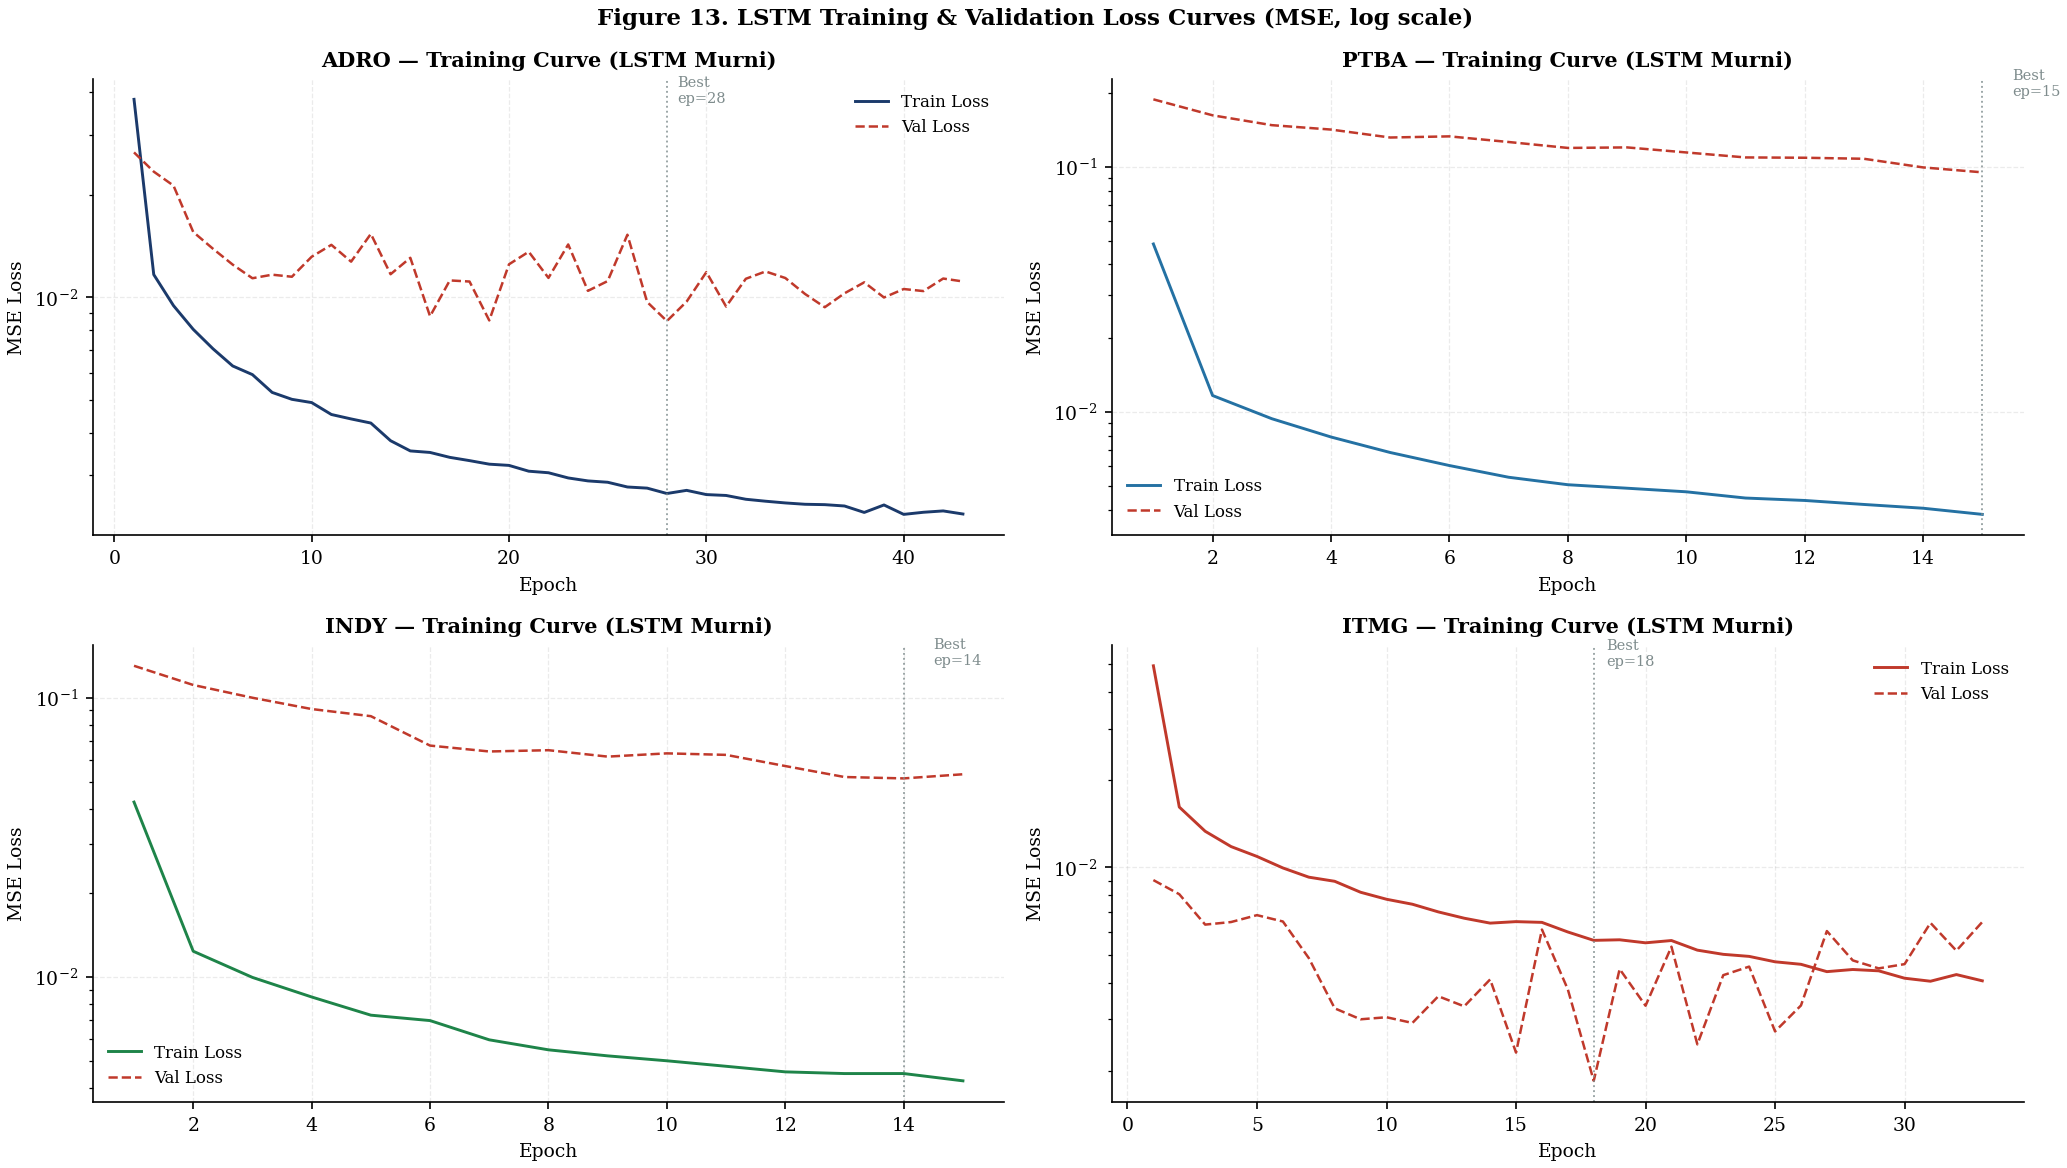

✓ fig13_lstm_training_curves.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    hist = lstm_history_pure[ticker].history
    ep   = range(1, len(hist["loss"]) + 1)

    ax.plot(ep, hist["loss"],
            color=warna, lw=1.4, label="Train Loss")

    ax.plot(ep, hist["val_loss"],
            color=C["red"], lw=1.2, ls="--", label="Val Loss")

    ax.set_title(
        f"{ticker} — Training Curve (LSTM Murni)",
        fontweight="bold",
        fontsize=10
    )

    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("MSE Loss", fontsize=9)
    ax.set_yscale("log")
    ax.legend(frameon=False, fontsize=8)

    # Tandai epoch terbaik
    best_ep = np.argmin(hist["val_loss"]) + 1
    ax.axvline(best_ep,
               color=C["gray"],
               lw=0.9,
               ls=":",
               alpha=0.8)

    ax.text(
        best_ep + 0.5,
        ax.get_ylim()[1] * 0.85,
        f"Best\nep={best_ep}",
        fontsize=7,
        color=C["gray"]
    )

fig.suptitle(
    "Figure 13. LSTM Training & Validation Loss Curves (MSE, log scale)",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

fig.savefig(
    f"{DIR_FIG}/fig13_lstm_training_curves.png",
    dpi=300
)

plt.show()

print("✓ fig13_lstm_training_curves.png")

## 9. Training LSTM pada Residual ARIMA (Komponen Hybrid)

LSTM **kedua** dilatih pada residual ARIMA:
- Input  : sequence residual ARIMA (e(t-W) … e(t-1))
- Output : residual satu langkah ke depan e(t)

Dengan demikian LSTM belajar memodelkan komponen **non-linear** yang tidak
berhasil ditangkap ARIMA.


In [26]:
def siapkan_data_residual(resid_train: pd.Series,
                          resid_test:  pd.Series,
                          window: int):
    """
    Sama persis dengan siapkan_data_lstm,
    hanya saja inputnya adalah residual ARIMA bukan harga.
    """
    scaler   = MinMaxScaler(feature_range=(-1, 1))
    train_sc = scaler.fit_transform(resid_train.values.reshape(-1,1)).flatten()
    # Untuk test, kita punya residual aktual selama train saja.
    # Saat inference, kita gunakan residual iteratif.
    X_tr, y_tr = buat_sequences(train_sc, window)
    return X_tr, y_tr, scaler


lstm_models_resid  = {}
lstm_history_resid = {}
scaler_resid       = {}

for ticker in ticker_list:
    print(f"Training LSTM residual — {ticker} ...", end=" ", flush=True)
    resid_seri = arima_residuals[ticker].dropna()

    X_tr, y_tr, scaler_r = siapkan_data_residual(
        resid_seri, resid_seri, WINDOW   # test tidak dipakai di sini
    )
    scaler_resid[ticker] = scaler_r

    mdl = bangun_lstm(WINDOW, LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE)

    cbs = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0),
    ]

    hist = mdl.fit(
        X_tr, y_tr,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cbs,
        verbose=0
    )

    lstm_models_resid[ticker]  = mdl
    lstm_history_resid[ticker] = hist
    ep_stop = len(hist.history["loss"])
    print(f"selesai  |  epochs={ep_stop}")

Training LSTM residual — ADRO ... selesai  |  epochs=68
Training LSTM residual — PTBA ... selesai  |  epochs=57
Training LSTM residual — INDY ... selesai  |  epochs=50
Training LSTM residual — ITMG ... selesai  |  epochs=100


## 10. Hybrid Forecast — Test Set

Formula kombinasi:
```
ŷ_hybrid(t) = ŷ_ARIMA(t)  +  ŷ_LSTM_resid(t)
```

1. `ŷ_ARIMA(t)` diambil dari rolling forecast Notebook 02
2. `ŷ_LSTM_resid(t)` diprediksi dari window terakhir residual training


In [27]:
def forecast_lstm_residual(model, scaler, resid_train, n_steps, window):
    """
    Forecast n_steps ke depan secara iteratif menggunakan window terakhir residual.
    Setiap prediksi ditambahkan ke buffer untuk prediksi berikutnya (recursive forecast).
    """
    train_sc = scaler.transform(
        resid_train.values[-window:].reshape(-1, 1)
    ).flatten()
    buffer = list(train_sc)
    preds  = []

    for _ in range(n_steps):
        x_input = np.array(buffer[-window:]).reshape(1, window, 1)
        pred_sc  = model.predict(x_input, verbose=0)[0, 0]
        pred_inv = scaler.inverse_transform([[pred_sc]])[0, 0]
        preds.append(pred_inv)
        buffer.append(pred_sc)

    return np.array(preds)


# ── Hitung hybrid forecast untuk test set ───────────────────────────────────
n_test         = len(df_test)
hybrid_forecast = {}

for ticker in ticker_list:
    resid_train = arima_residuals[ticker].dropna()
    lstm_resid_pred = forecast_lstm_residual(
        lstm_models_resid[ticker],
        scaler_resid[ticker],
        resid_train,
        n_steps=n_test,
        window=WINDOW
    )

    arima_fc_arr = arima_forecast[ticker].values[:n_test]
    hybrid_fc    = arima_fc_arr + lstm_resid_pred[:len(arima_fc_arr)]

    hybrid_forecast[ticker] = pd.Series(
        hybrid_fc,
        index=df_test.index[:len(hybrid_fc)]
    )

print("Hybrid forecast selesai:")
for t in ticker_list:
    print(f"  {t}: {len(hybrid_forecast[t])} observasi")

Hybrid forecast selesai:
  ADRO: 522 observasi
  PTBA: 522 observasi
  INDY: 522 observasi
  ITMG: 522 observasi


## 11. Evaluasi Metrik — ARIMA vs LSTM vs Hybrid (Tabel 5)

In [28]:
def hitung_metrik(aktual, prediksi, nama_model, emiten):
    mae  = mean_absolute_error(aktual, prediksi)
    rmse = np.sqrt(mean_squared_error(aktual, prediksi))
    mape = np.mean(np.abs((aktual - prediksi) / aktual)) * 100
    r2   = r2_score(aktual, prediksi)
    return {
        "Emiten": emiten,
        "Model":  nama_model,
        "MAE":    round(mae,  4),
        "RMSE":   round(rmse, 4),
        "MAPE (%)": round(mape, 4),
        "R²":     round(r2,   6),
    }


rows_compare = []

for ticker in ticker_list:
    aktual = df_test[ticker].values
    n_fc   = min(len(aktual), len(arima_forecast[ticker]),
                 len(lstm_pred_pure[ticker]),
                 len(hybrid_forecast[ticker]))
    aktual = aktual[:n_fc]

    rows_compare.append(
        hitung_metrik(aktual,
                      arima_forecast[ticker].values[:n_fc],
                      f"ARIMA{best_orders[ticker]}", ticker))
    rows_compare.append(
        hitung_metrik(aktual,
                      lstm_pred_pure[ticker][:n_fc],
                      "LSTM (murni)", ticker))
    rows_compare.append(
        hitung_metrik(aktual,
                      hybrid_forecast[ticker].values[:n_fc],
                      "Hybrid ARIMA-LSTM", ticker))

tbl5 = pd.DataFrame(rows_compare)
tbl5.to_csv(f"{DIR_DATA}/tabel05_perbandingan_model.csv", index=False)
print("✓  tabel05_perbandingan_model.csv\n")
tbl5

✓  tabel05_perbandingan_model.csv



,Emiten,Model,MAE,RMSE,MAPE (%),R²
0,ADRO,"ARIMA(3, 1, 3)",95.2167,120.3472,1.9879,0.985972
1,ADRO,LSTM (murni),857.0574,1030.2859,16.4719,-0.028103
2,ADRO,Hybrid ARIMA-LSTM,95.2167,120.3474,1.9879,0.985972
3,PTBA,"ARIMA(1, 1, 3)",240.1212,305.2328,1.7093,0.989435
4,PTBA,LSTM (murni),6000.0389,6487.4781,40.9356,-3.772470
5,PTBA,Hybrid ARIMA-LSTM,239.9808,305.0458,1.7089,0.989448
6,INDY,"ARIMA(1, 1, 3)",1815.7472,2282.3825,1.7918,0.975938
7,INDY,LSTM (murni),9072.3670,10759.5713,8.9061,0.465248
8,INDY,Hybrid ARIMA-LSTM,1815.6804,2281.2181,1.7922,0.975962
9,ITMG,"ARIMA(3, 1, 3)",0.0809,0.1262,4.7750,0.995548


## 12. Visualisasi Perbandingan Tiga Model — Test Set (Figure 14)

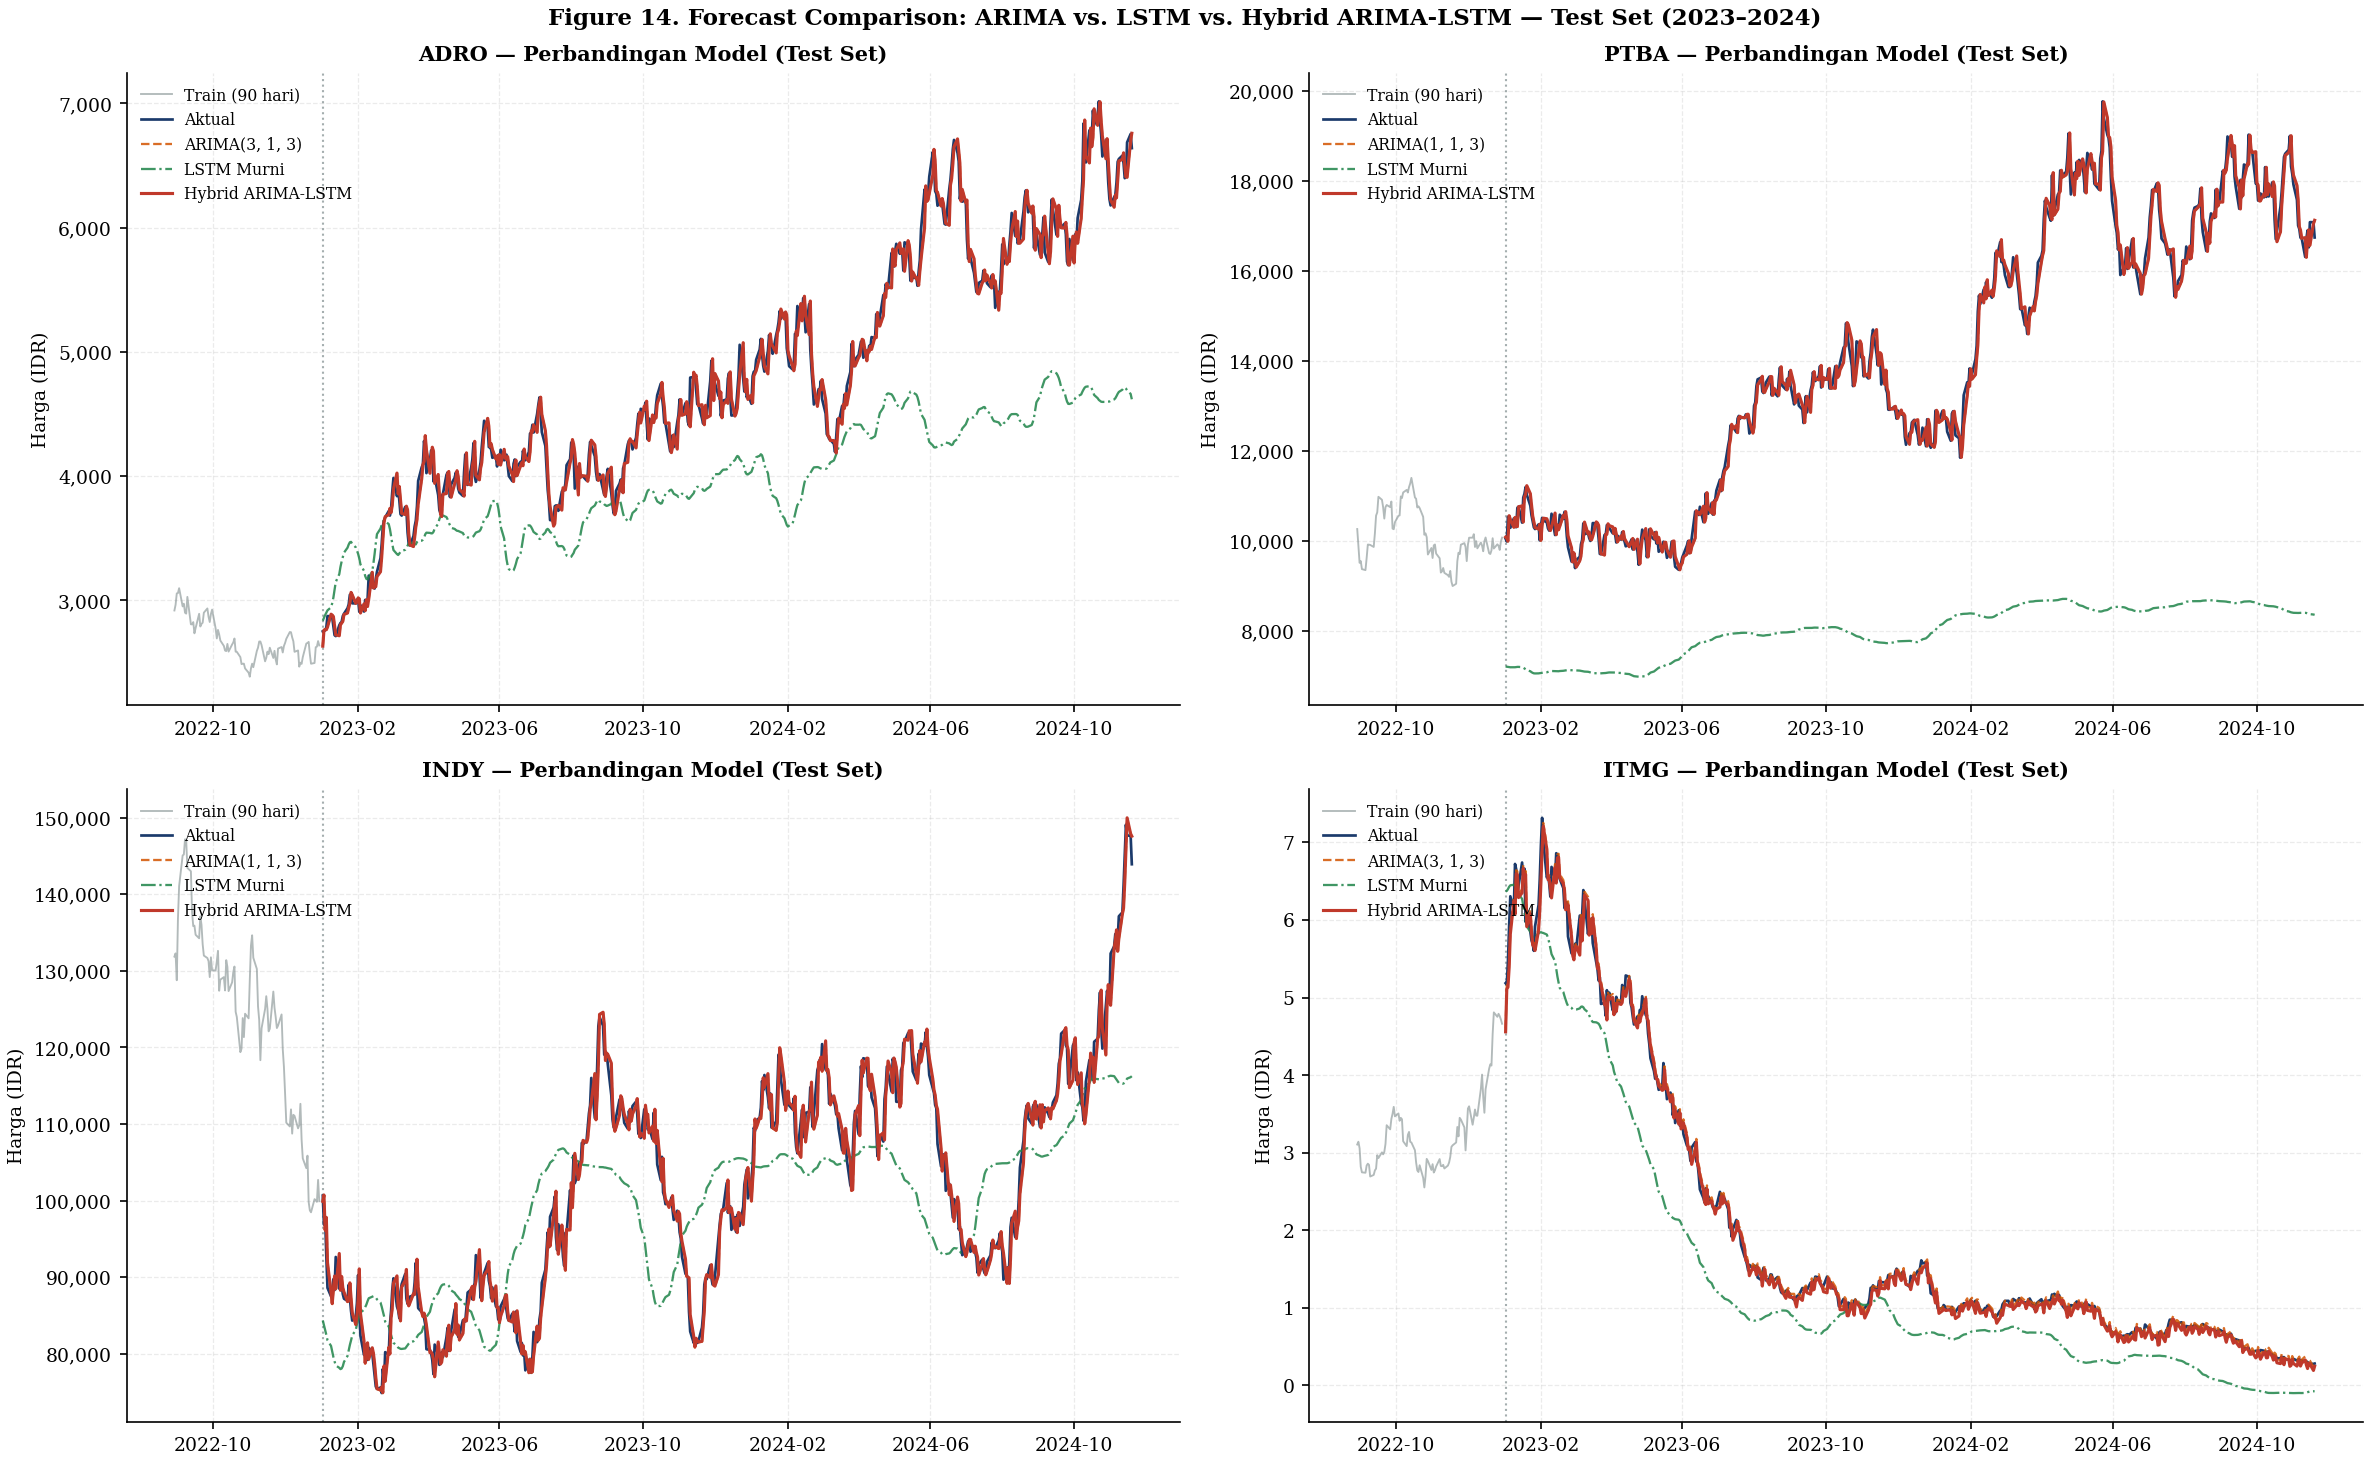

✓  fig14_perbandingan_model_forecast.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    aktual = df_test[ticker]
    n_fc   = min(len(aktual),
                 len(arima_forecast[ticker]),
                 len(lstm_pred_pure[ticker]),
                 len(hybrid_forecast[ticker]))
    idx    = aktual.index[:n_fc]

    ax.plot(df_train[ticker].index[-90:],
            df_train[ticker].iloc[-90:],
            color=C["gray"], lw=0.9, alpha=0.6, label="Train (90 hari)")
    ax.axvline(df_test.index[0], color=C["gray"], lw=1.0, ls=":", alpha=0.7)

    ax.plot(idx, aktual.values[:n_fc],
            color=C["navy"], lw=1.3, label="Aktual")
    ax.plot(idx, arima_forecast[ticker].values[:n_fc],
            color=C["orange"], lw=1.1, ls="--", alpha=0.85,
            label=f"ARIMA{best_orders[ticker]}")
    ax.plot(idx, lstm_pred_pure[ticker][:n_fc],
            color=C["green"], lw=1.1, ls="-.", alpha=0.85,
            label="LSTM Murni")
    ax.plot(idx, hybrid_forecast[ticker].values[:n_fc],
            color=C["red"], lw=1.5,
            label="Hybrid ARIMA-LSTM")

    ax.set_title(f"{ticker} — Perbandingan Model (Test Set)",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("Harga (IDR)", fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.legend(frameon=False, fontsize=7.5, loc="upper left")

fig.suptitle(
    "Figure 14. Forecast Comparison: ARIMA vs. LSTM vs. Hybrid ARIMA-LSTM — Test Set (2023–2024)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig14_perbandingan_model_forecast.png", dpi=300)
plt.show()
print("✓  fig14_perbandingan_model_forecast.png")

## 13. Grouped Bar Chart — Perbandingan Metrik (Figure 15)

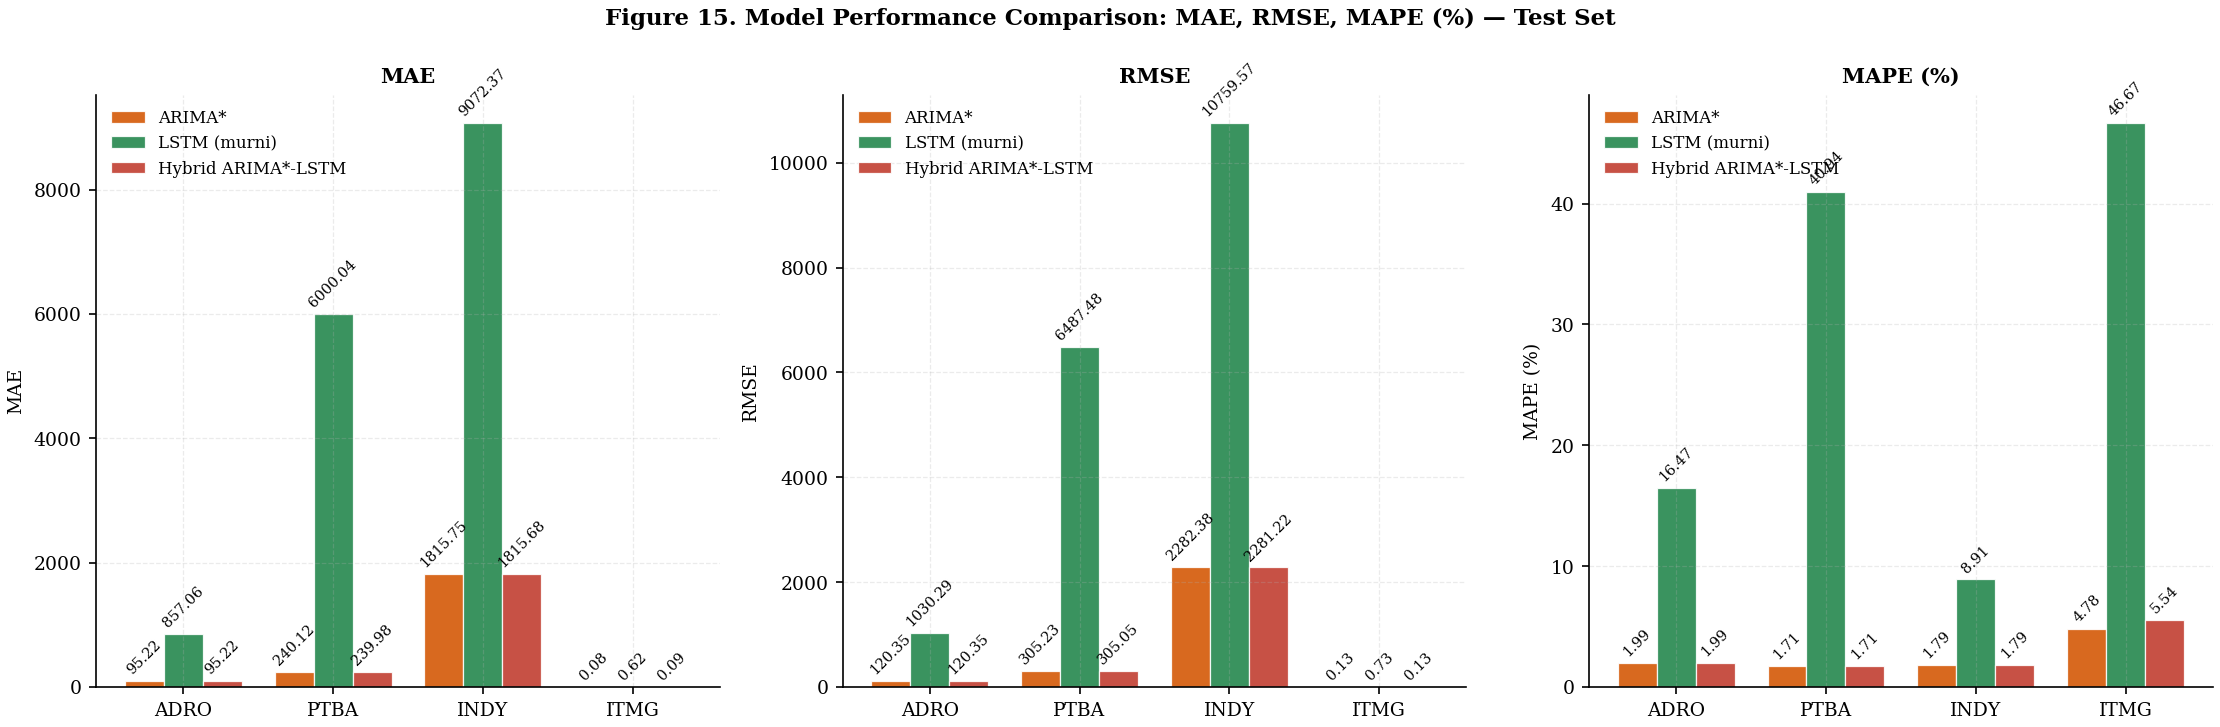

✓  fig15_metrics_grouped_bar.png


In [30]:
metrik_cols  = ["MAE", "RMSE", "MAPE (%)"]
model_labels = [f"ARIMA{best_orders[t]}" for t in ticker_list]
model_labels_uniq = ["ARIMA", "LSTM Murni", "Hybrid"]
warna_model  = [C["orange"], C["green"], C["red"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metrik in zip(axes, metrik_cols):
    x     = np.arange(len(ticker_list))
    width = 0.26
    for i, (model_name, warna) in enumerate(
        zip(["ARIMA", "LSTM (murni)", "Hybrid ARIMA-LSTM"], warna_model)
    ):
        vals  = tbl5[tbl5["Model"].str.startswith(model_name.split()[0])][metrik].values
        bars  = ax.bar(x + i*width, vals[:len(ticker_list)],
                       width, color=warna, edgecolor="white",
                       linewidth=0.6, alpha=0.88,
                       label=model_name.replace("ARIMA","ARIMA*"))
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2, rotation=45)

    ax.set_xticks(x + width)
    ax.set_xticklabels(ticker_list, fontsize=9)
    ax.set_title(f"{metrik}", fontweight="bold", fontsize=10)
    ax.set_ylabel(metrik, fontsize=9)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    "Figure 15. Model Performance Comparison: MAE, RMSE, MAPE (%) — Test Set",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig15_metrics_grouped_bar.png", dpi=300)
plt.show()
print("✓  fig15_metrics_grouped_bar.png")

## 14. Scatter Plot Aktual vs Prediksi — Hybrid (Figure 16)

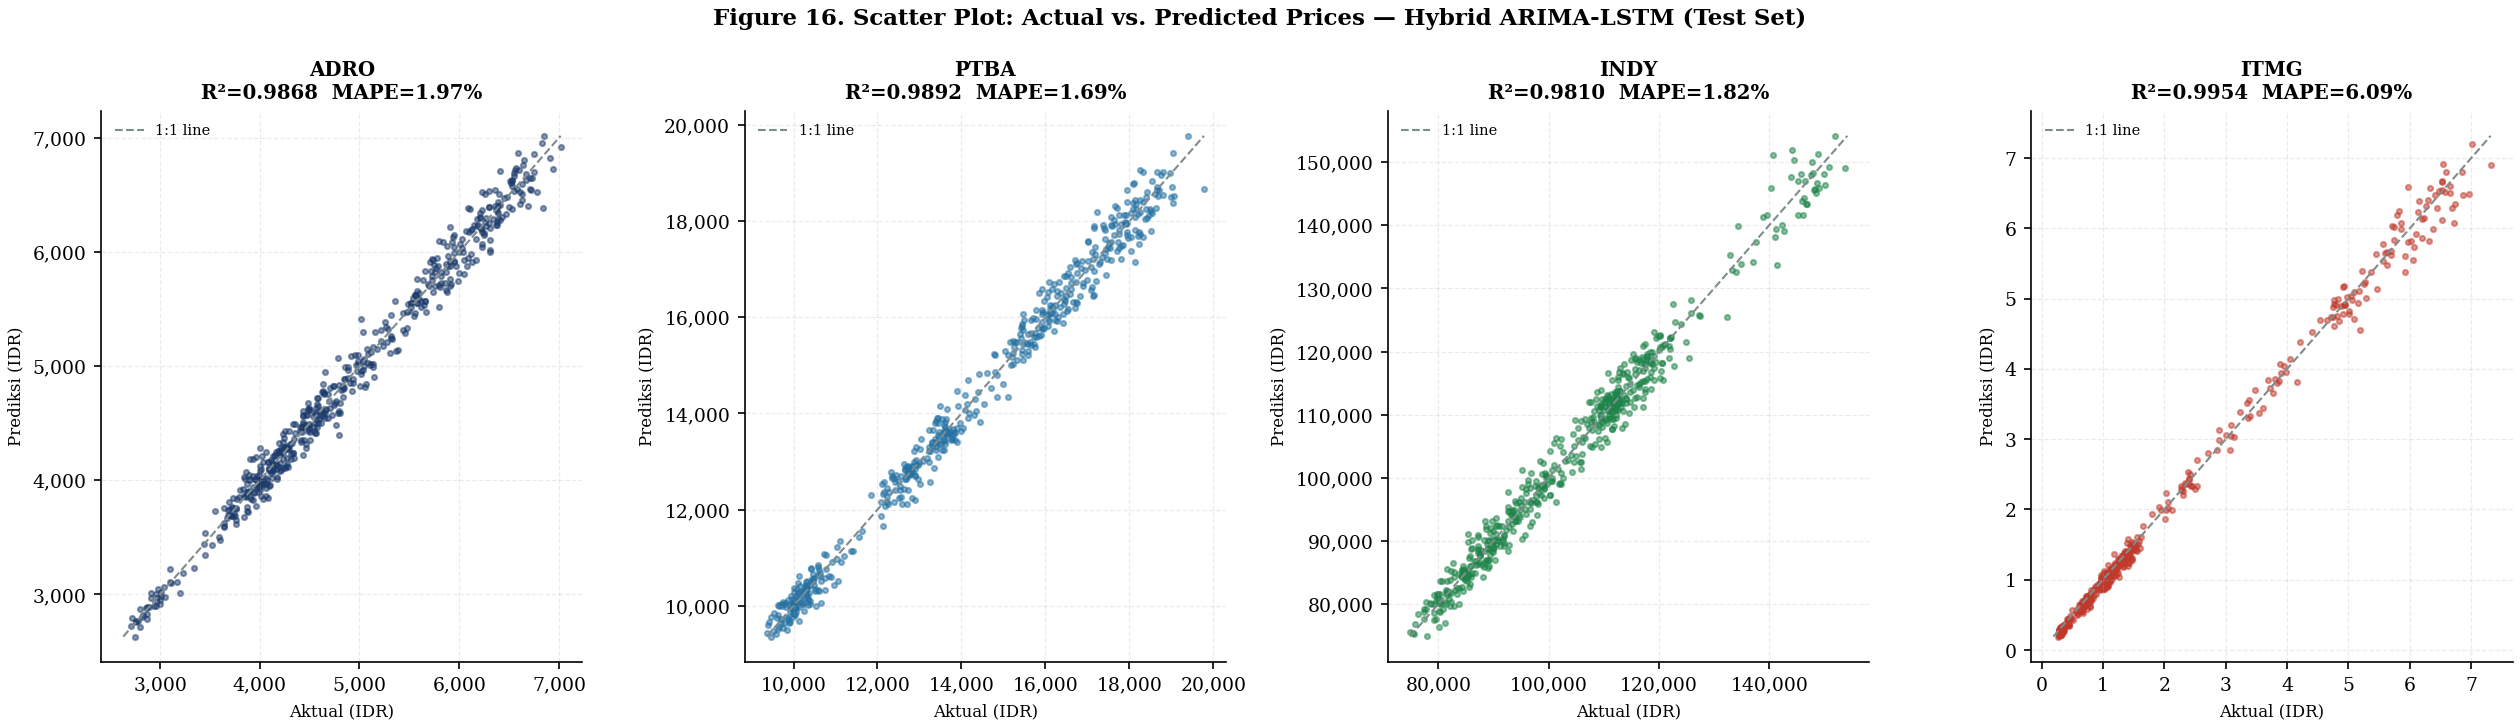

✓  fig16_scatter_aktual_prediksi.png


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    aktual = df_test[ticker].values
    pred   = hybrid_forecast[ticker].values
    n_fc   = min(len(aktual), len(pred))
    aktual, pred = aktual[:n_fc], pred[:n_fc]

    ax.scatter(aktual, pred, s=6, color=warna, alpha=0.50)
    lims = [min(aktual.min(), pred.min()), max(aktual.max(), pred.max())]
    ax.plot(lims, lims, color=C["gray"], lw=1.0, ls="--", label="1:1 line")

    r2   = r2_score(aktual, pred)
    mape = np.mean(np.abs((aktual-pred)/aktual))*100

    ax.set_title(f"{ticker}\nR²={r2:.4f}  MAPE={mape:.2f}%",
                 fontweight="bold", fontsize=9.5)
    ax.set_xlabel("Aktual (IDR)", fontsize=8)
    ax.set_ylabel("Prediksi (IDR)", fontsize=8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.legend(frameon=False, fontsize=7)

fig.suptitle(
    "Figure 16. Scatter Plot: Actual vs. Predicted Prices — Hybrid ARIMA-LSTM (Test Set)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig16_scatter_aktual_prediksi.png", dpi=300)
plt.show()
print("✓  fig16_scatter_aktual_prediksi.png")

## 15. Analisis Error Residual Hybrid (Figure 17)

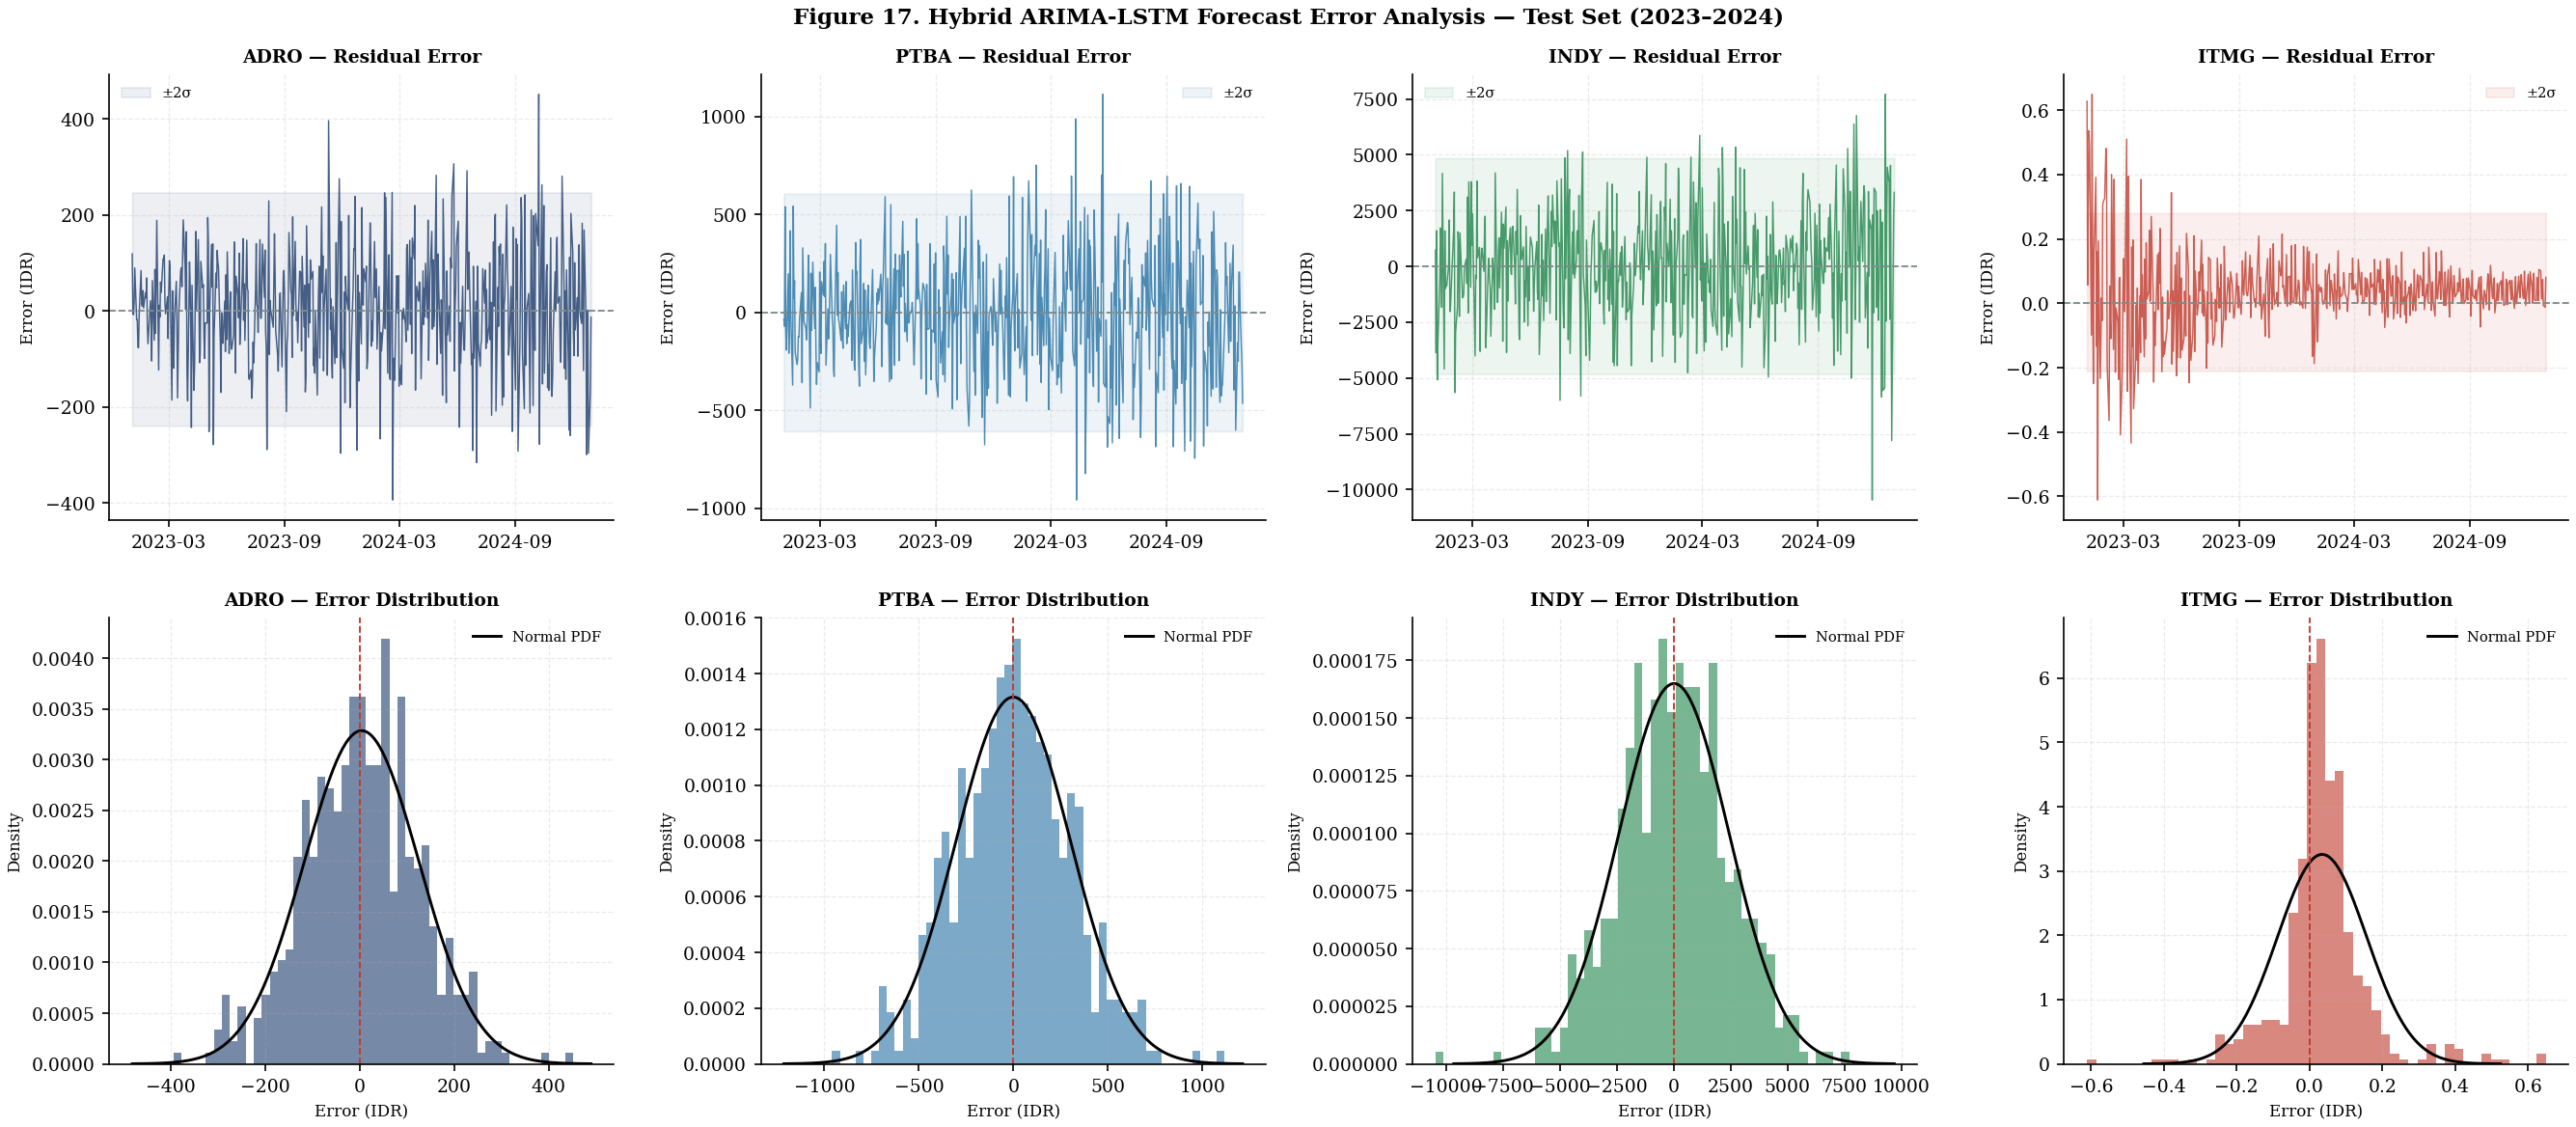

✓  fig17_hybrid_error_analysis.png


In [32]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (ticker, warna) in enumerate(zip(ticker_list, warna_saham)):
    aktual = df_test[ticker].values
    pred   = hybrid_forecast[ticker].values
    n_fc   = min(len(aktual), len(pred))
    err    = aktual[:n_fc] - pred[:n_fc]
    idx    = df_test.index[:n_fc]

    # Baris atas: error time plot
    ax_ts = axes[0, col]
    ax_ts.plot(idx, err, color=warna, lw=0.7, alpha=0.8)
    ax_ts.axhline(0, color=C["gray"], lw=0.9, ls="--")
    ax_ts.fill_between(idx,
                       err.mean()-2*err.std(),
                       err.mean()+2*err.std(),
                       alpha=0.08, color=warna, label="±2σ")
    ax_ts.set_title(f"{ticker} — Residual Error", fontweight="bold", fontsize=9)
    ax_ts.set_ylabel("Error (IDR)", fontsize=8)
    ax_ts.legend(frameon=False, fontsize=7)
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    # Baris bawah: distribusi error
    ax_dist = axes[1, col]
    ax_dist.hist(err, bins=50, color=warna, alpha=0.60, density=True, edgecolor="none")
    mu_e, std_e = err.mean(), err.std()
    x_fit = np.linspace(mu_e-4*std_e, mu_e+4*std_e, 300)
    ax_dist.plot(x_fit, stats.norm.pdf(x_fit, mu_e, std_e),
                 color="black", lw=1.4, label="Normal PDF")
    ax_dist.axvline(0, color=C["red"], lw=0.9, ls="--")
    ax_dist.set_title(f"{ticker} — Error Distribution", fontweight="bold", fontsize=9)
    ax_dist.set_xlabel("Error (IDR)", fontsize=8)
    ax_dist.set_ylabel("Density", fontsize=8)
    ax_dist.legend(frameon=False, fontsize=7)

fig.suptitle(
    "Figure 17. Hybrid ARIMA-LSTM Forecast Error Analysis — Test Set (2023–2024)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(h_pad=2.0)
fig.savefig(f"{DIR_FIG}/fig17_hybrid_error_analysis.png", dpi=300)
plt.show()
print("✓  fig17_hybrid_error_analysis.png")

## 16. Forecast Jangka Panjang 2025–2045 (Figure 18)

Forecasting 21 tahun ke depan menggunakan **recursive multi-step forecast**:
- ARIMA: forecast iteratif menggunakan statsmodels `.forecast()`
- LSTM residual: recursive buffer prediction
- Interval kepercayaan 95% dari bootstrap simulasi


In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX

def forecast_arima_longterm(series_full, order, n_steps):
    """Forecast n_steps ke depan dari model ARIMA yang di-fit pada data penuh."""
    mdl = _SARIMAX(
        series_full, order=order, trend="n",
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False, method="lbfgs", maxiter=300)
    fc_obj = mdl.get_forecast(steps=n_steps)
    fc_mean = fc_obj.predicted_mean
    ci      = fc_obj.conf_int(alpha=0.05)
    return fc_mean.values, ci.values[:, 0], ci.values[:, 1]


# Horizon: 2025-01-01 sampai 2045-12-31 (hari kerja)
tanggal_fc  = pd.bdate_range("2025-01-02", "2045-12-31")
N_STEPS     = len(tanggal_fc)

print(f"Horizon forecast: {tanggal_fc[0].date()} → {tanggal_fc[-1].date()}")
print(f"Jumlah hari kerja: {N_STEPS:,}\n")

longterm_results = {}

for ticker in ticker_list:
    print(f"  Long-term forecast {ticker} ...", end=" ", flush=True)

    # Data penuh (train + test)
    series_full = df[ticker].dropna()

    # ── ARIMA long-term ──────────────────────────────────────────────
    fc_mean, ci_lo, ci_hi = forecast_arima_longterm(
        series_full, best_orders[ticker], N_STEPS
    )

    # ── LSTM residual iteratif ───────────────────────────────────────
    resid_full = pd.concat([
        arima_residuals[ticker],
        pd.Series(np.zeros(len(df_test)), index=df_test.index)  # proxy
    ]).dropna()

    lstm_resid_lt = forecast_lstm_residual(
        lstm_models_resid[ticker],
        scaler_resid[ticker],
        resid_full,
        n_steps=N_STEPS,
        window=WINDOW
    )

    hybrid_lt = fc_mean + lstm_resid_lt

    longterm_results[ticker] = {
        "dates":      tanggal_fc,
        "arima_mean": fc_mean,
        "ci_lo":      ci_lo,
        "ci_hi":      ci_hi,
        "hybrid":     hybrid_lt,
    }
    print("selesai")

print("\nForecast 2025–2045 selesai.")

Horizon forecast: 2025-01-02 → 2045-12-29
Jumlah hari kerja: 5,477

  Long-term forecast ADRO ... 

c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


selesai
  Long-term forecast PTBA ... 

c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


selesai
  Long-term forecast INDY ... 

c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


selesai
  Long-term forecast ITMG ... 

c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


selesai

Forecast 2025–2045 selesai.


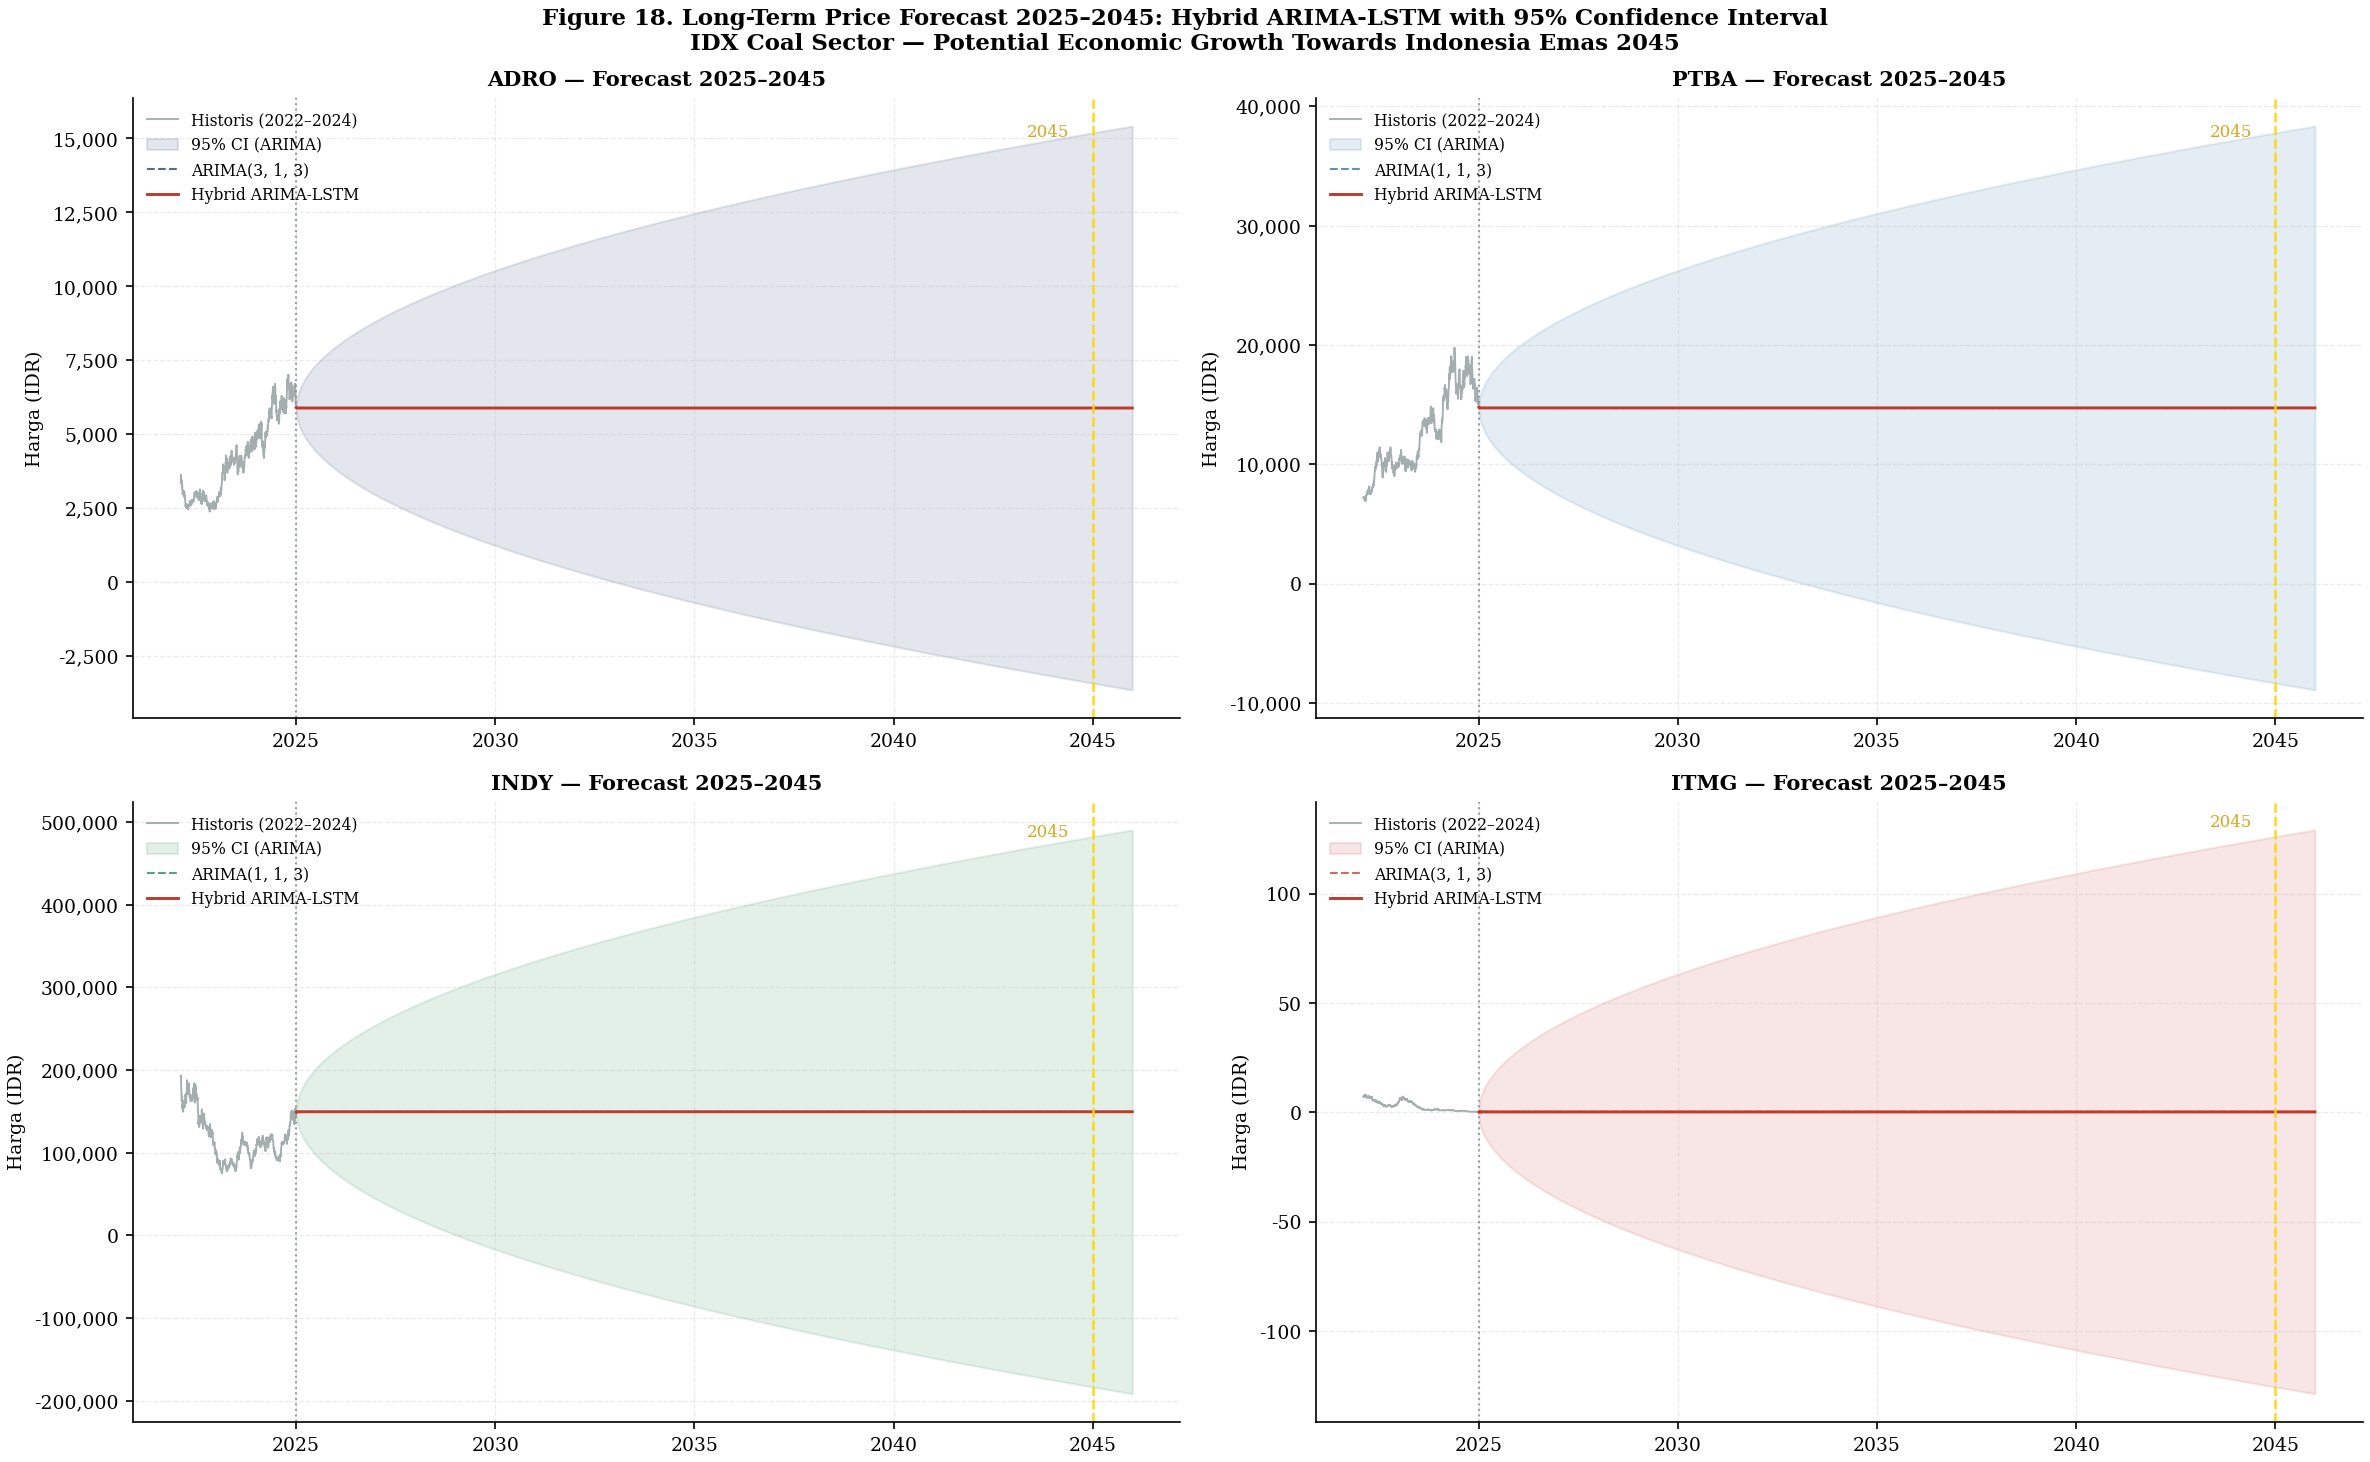

✓  fig18_forecast_2025_2045.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    res = longterm_results[ticker]

    # Data historis (ringkas — 3 tahun terakhir)
    hist_tail = df[ticker].iloc[-756:]   # ~3 tahun hari kerja
    ax.plot(hist_tail.index, hist_tail,
            color=C["gray"], lw=0.9, alpha=0.7, label="Historis (2022–2024)")

    # Garis pemisah
    ax.axvline(pd.Timestamp("2025-01-01"),
               color=C["gray"], lw=1.0, ls=":", alpha=0.8)

    # ARIMA CI band
    ax.fill_between(res["dates"], res["ci_lo"], res["ci_hi"],
                    alpha=0.12, color=warna, label="95% CI (ARIMA)")
    ax.plot(res["dates"], res["arima_mean"],
            color=warna, lw=1.0, ls="--", alpha=0.75,
            label=f"ARIMA{best_orders[ticker]}")

    # Hybrid
    ax.plot(res["dates"], res["hybrid"],
            color=C["red"], lw=1.4,
            label="Hybrid ARIMA-LSTM")

    # Milestone Indonesia Emas 2045
    ax.axvline(pd.Timestamp("2045-01-01"),
               color="gold", lw=1.2, ls="--", alpha=0.9)
    ax.text(pd.Timestamp("2044-06-01"),
            ax.get_ylim()[1]*0.92 if ax.get_ylim()[1] > 0 else 1,
            "2045", fontsize=8, color="goldenrod", ha="right")

    ax.set_title(f"{ticker} — Forecast 2025–2045",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("Harga (IDR)", fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.legend(frameon=False, fontsize=7.5)

fig.suptitle(
    "Figure 18. Long-Term Price Forecast 2025–2045: Hybrid ARIMA-LSTM with 95% Confidence Interval\n"
    "IDX Coal Sector — Potential Economic Growth Towards Indonesia Emas 2045",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig18_forecast_2025_2045.png", dpi=300)
plt.show()
print("✓  fig18_forecast_2025_2045.png")

## 17. Tabel Ringkasan Forecast Milestone 2025–2045 (Tabel 6)

In [35]:
milestone_years = [2025, 2027, 2030, 2035, 2040, 2045]
rows_fc = []

for ticker in ticker_list:
    res = longterm_results[ticker]
    harga_akhir_hist = df[ticker].dropna().iloc[-1]
    for yr in milestone_years:
        # Ambil nilai forecast di awal tahun tersebut
        mask = [d.year == yr and d.month == 1 for d in res["dates"]]
        idx_yr = np.where(mask)[0]
        if len(idx_yr) == 0:
            continue
        i = idx_yr[0]
        rows_fc.append({
            "Emiten":          ticker,
            "Tahun":           yr,
            "ARIMA Forecast":  round(res["arima_mean"][i], 2),
            "Hybrid Forecast": round(res["hybrid"][i],     2),
            "CI Lower (95%)":  round(res["ci_lo"][i],      2),
            "CI Upper (95%)":  round(res["ci_hi"][i],      2),
            "Growth vs 2024 (%)": round(
                (res["hybrid"][i] / harga_akhir_hist - 1) * 100, 2
            )
        })

tbl6 = pd.DataFrame(rows_fc)
tbl6.to_csv(f"{DIR_DATA}/tabel06_forecast_milestone_2045.csv", index=False)
print("✓  tabel06_forecast_milestone_2045.csv\n")
tbl6

✓  tabel06_forecast_milestone_2045.csv



,Emiten,Tahun,ARIMA Forecast,Hybrid Forecast,CI Lower (95%),CI Upper (95%),Growth vs 2024 (%)
0,ADRO,2025,5897.50,5897.50,5779.01,6016.00,-0.13
1,ADRO,2027,5888.39,5888.39,2946.84,8829.95,-0.29
2,ADRO,2030,5888.39,5888.39,1238.28,10538.51,-0.29
3,ADRO,2035,5888.39,5888.39,-688.28,12465.07,-0.29
4,ADRO,2040,5888.39,5888.39,-2167.55,13944.34,-0.29
5,ADRO,2045,5888.39,5888.39,-3414.51,15191.29,-0.29
6,PTBA,2025,14750.45,14758.30,14454.23,15046.68,-0.03
7,PTBA,2027,14709.97,14717.86,7417.78,22002.16,-0.30
8,PTBA,2030,14709.97,14717.86,3182.51,26237.43,-0.30
9,PTBA,2035,14709.97,14717.86,-1593.23,31013.17,-0.30


## 18. Heatmap Perbandingan MAPE Seluruh Model × Emiten (Figure 19)

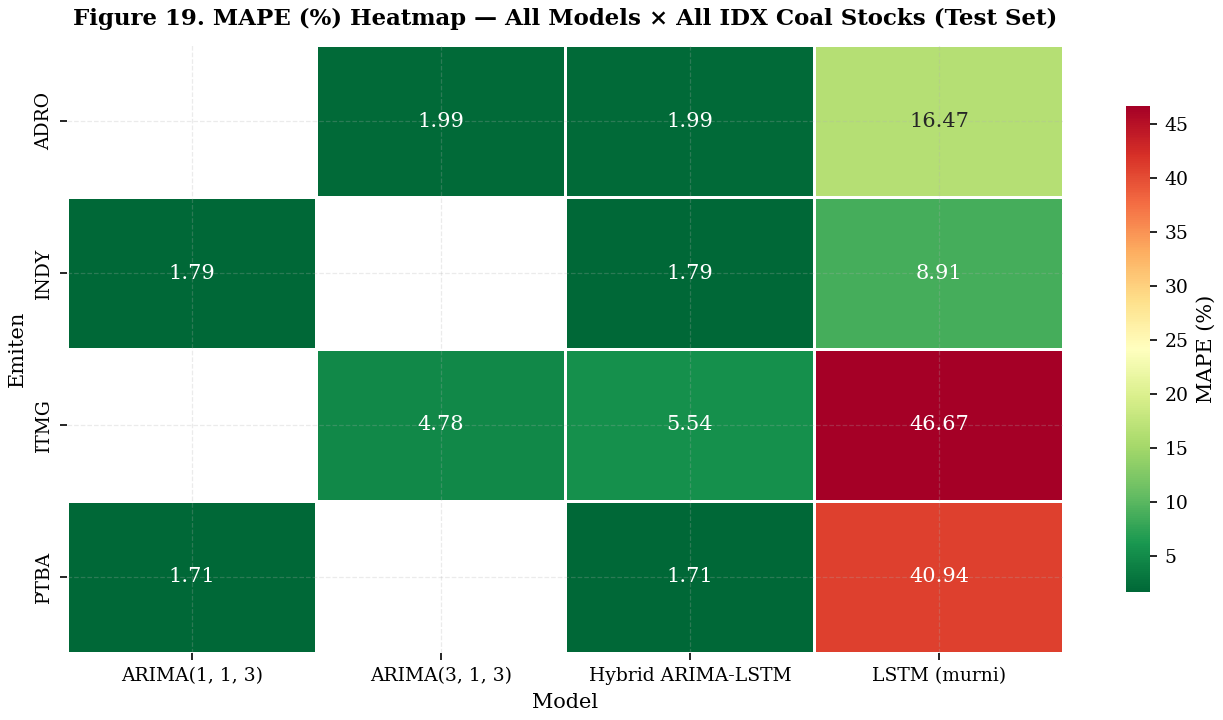

✓  fig19_mape_heatmap.png


In [36]:
pivot_mape = tbl5.pivot(index="Emiten", columns="Model", values="MAPE (%)")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_mape, ax=ax, annot=True, fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 10},
    cbar_kws={"label": "MAPE (%)", "shrink": 0.8}
)
ax.set_title(
    "Figure 19. MAPE (%) Heatmap — All Models × All IDX Coal Stocks (Test Set)",
    fontsize=11, fontweight="bold", pad=10
)
ax.set_xlabel("Model", fontsize=10)
ax.set_ylabel("Emiten", fontsize=10)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig19_mape_heatmap.png", dpi=300)
plt.show()
print("✓  fig19_mape_heatmap.png")

## 19. Radar Chart Perbandingan Model (Figure 20)

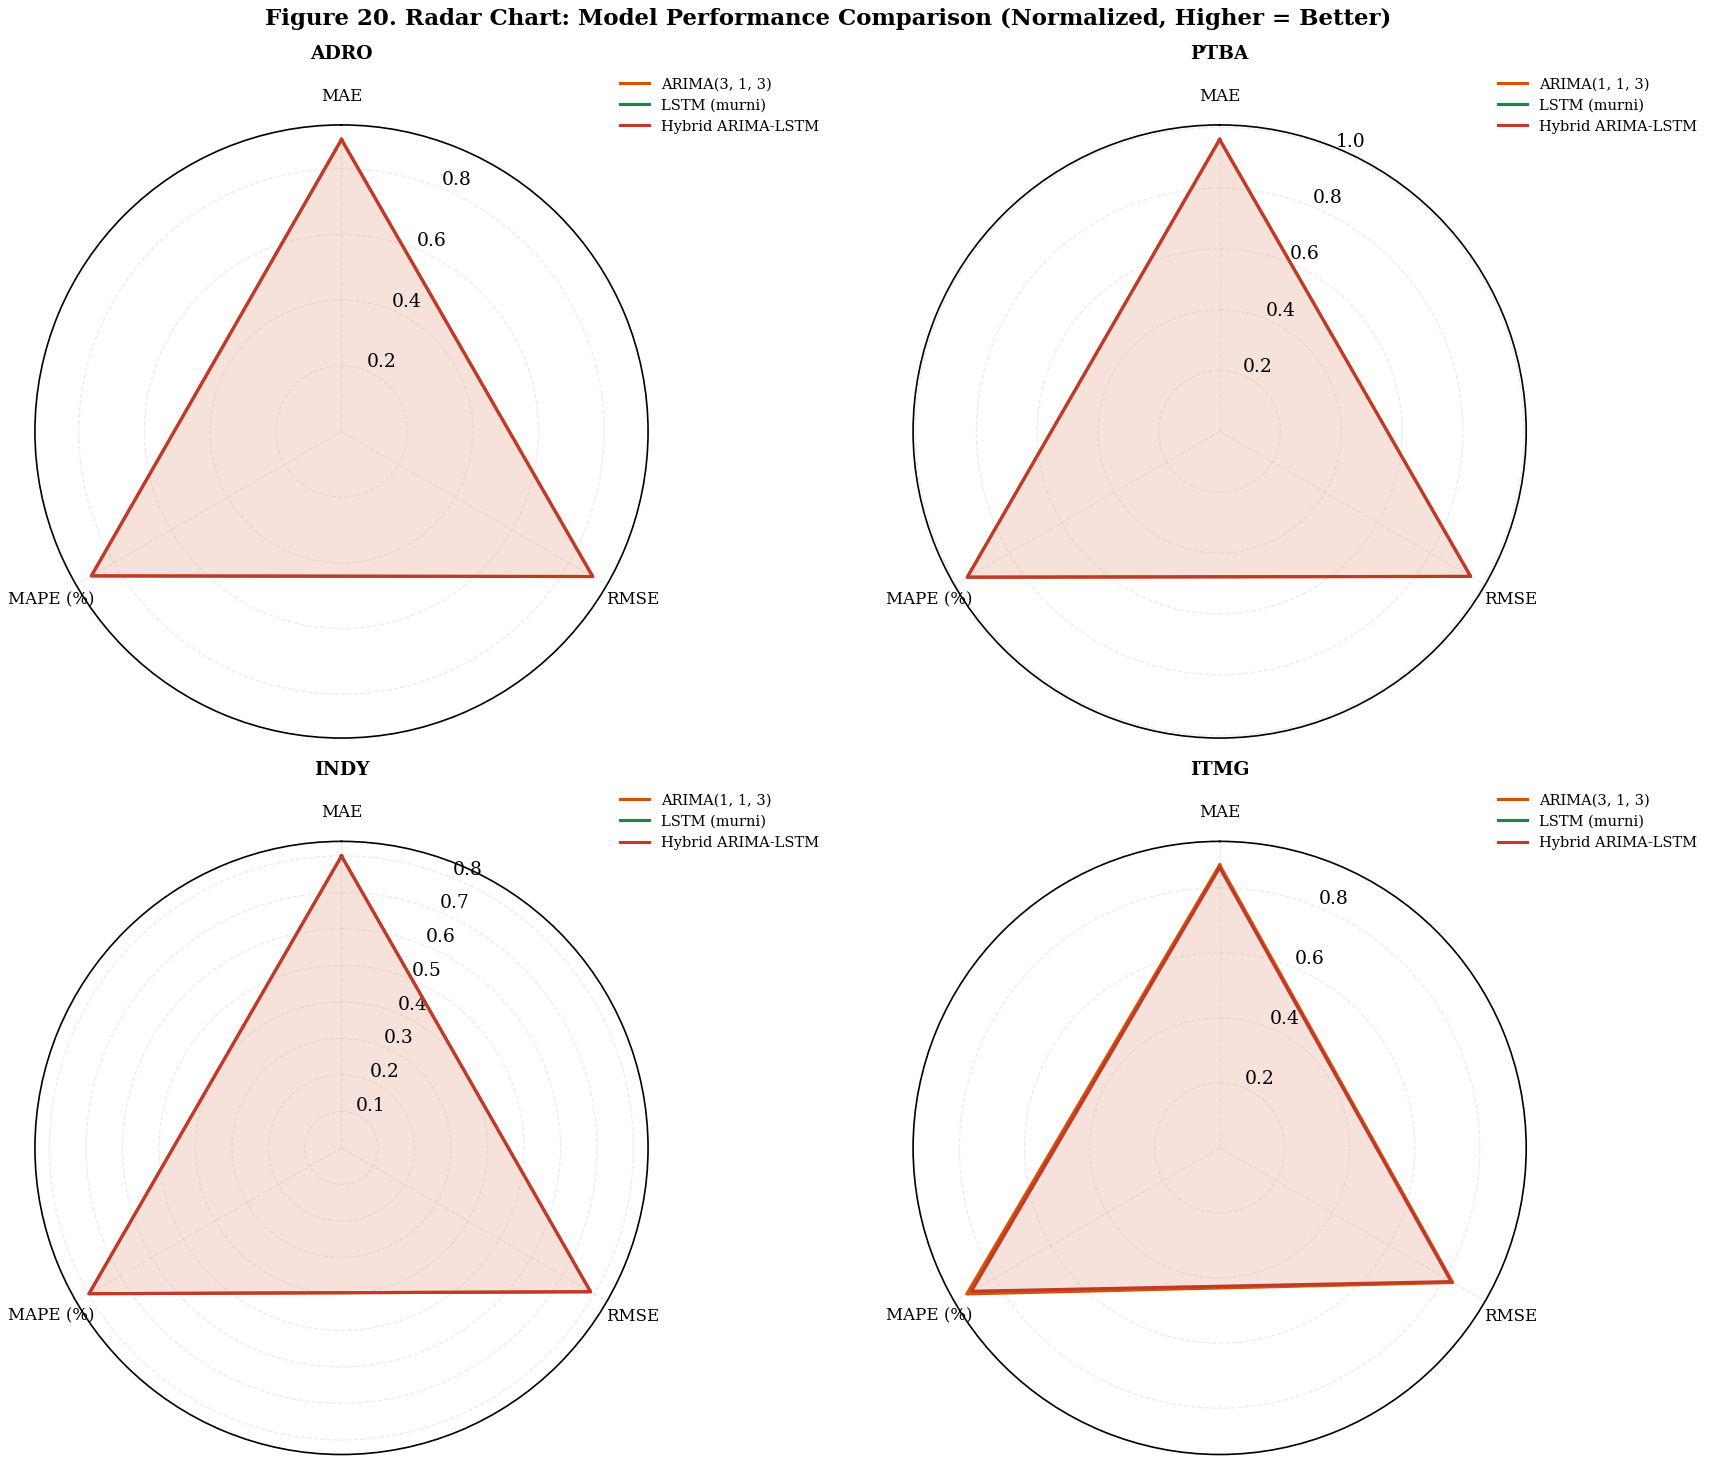

✓  fig20_radar_chart_model.png


In [37]:
from matplotlib.patches import FancyArrowPatch

def radar_chart(ax, values_dict, labels, title=""):
    """Plot radar chart sederhana menggunakan polar axes."""
    N      = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=9, pad=14)

    warna_model_r = [C["orange"], C["green"], C["red"]]
    for (model_name, vals), warna in zip(values_dict.items(), warna_model_r):
        vals_closed = list(vals) + [vals[0]]
        ax.plot(angles, vals_closed, color=warna, lw=1.5, label=model_name)
        ax.fill(angles, vals_closed, color=warna, alpha=0.08)
    ax.legend(frameon=False, fontsize=7, loc="upper right",
              bbox_to_anchor=(1.3, 1.1))


# Normalisasi metrik ke [0,1] (lebih rendah = lebih baik, diinvert untuk radar)
metrik_radar = ["MAE", "RMSE", "MAPE (%)"]
fig, axes    = plt.subplots(2, 2, figsize=(12, 10),
                            subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, ticker in zip(axes, ticker_list):
    sub    = tbl5[tbl5["Emiten"] == ticker]
    vals_d = {}
    for _, row in sub.iterrows():
        vals_d[row["Model"]] = [row[m] for m in metrik_radar]

    # Normalisasi: invert supaya lebih tinggi = lebih baik di radar
    all_vals = np.array(list(vals_d.values()))
    max_v    = all_vals.max(axis=0)
    vals_norm = {k: list(1 - v/max_v) for k, v in zip(vals_d.keys(),
                                                        all_vals)}
    radar_chart(ax, vals_norm, metrik_radar, title=ticker)

fig.suptitle(
    "Figure 20. Radar Chart: Model Performance Comparison (Normalized, Higher = Better)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig20_radar_chart_model.png", dpi=300)
plt.show()
print("✓  fig20_radar_chart_model.png")

## 20. Simpan Model & Artefak

In [38]:
import os

# Simpan model LSTM (format Keras SavedModel)
for ticker in ticker_list:
    path_pure  = f"{DIR_MDL}/lstm_pure_{ticker}.keras"
    path_resid = f"{DIR_MDL}/lstm_resid_{ticker}.keras"
    lstm_models_pure[ticker].save(path_pure)
    lstm_models_resid[ticker].save(path_resid)

print("Model tersimpan:")
for f in sorted(os.listdir(DIR_MDL)):
    print(f"  {DIR_MDL}/{f}")

# Simpan scaler
with open(f"{DIR_DATA}/scalers_lstm.pkl", "wb") as f:
    pickle.dump({t: data_lstm[t]["scaler"] for t in ticker_list}, f)
with open(f"{DIR_DATA}/scalers_resid.pkl", "wb") as f:
    pickle.dump(scaler_resid, f)

# Simpan forecast jangka panjang
with open(f"{DIR_DATA}/longterm_forecast_2045.pkl", "wb") as f:
    pickle.dump(longterm_results, f)

print("\nArtefak tersimpan:")
for fn in ["scalers_lstm.pkl","scalers_resid.pkl","longterm_forecast_2045.pkl"]:
    print(f"  {DIR_DATA}/{fn}")

Model tersimpan:
  models/lstm_pure_ADRO.keras
  models/lstm_pure_INDY.keras
  models/lstm_pure_ITMG.keras
  models/lstm_pure_PTBA.keras
  models/lstm_resid_ADRO.keras
  models/lstm_resid_INDY.keras
  models/lstm_resid_ITMG.keras
  models/lstm_resid_PTBA.keras

Artefak tersimpan:
  C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL/scalers_lstm.pkl
  C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL/scalers_resid.pkl
  C:\Users\dayinta agustina\Downloads\Documents\PENELITIAN FMIPA FORECAST FINAL/longterm_forecast_2045.pkl


## 21. Rangkuman Hasil Akhir

In [39]:
print("=" * 65)
print("  RANGKUMAN AKHIR — HYBRID ARIMA-LSTM  |  JUTIF 2025")
print("=" * 65)

best_model_per_ticker = {}
for ticker in ticker_list:
    sub = tbl5[tbl5["Emiten"] == ticker].sort_values("MAPE (%)")
    best = sub.iloc[0]
    best_model_per_ticker[ticker] = best["Model"]
    print(f"  {ticker}")
    print(f"    Model terbaik  : {best['Model']}")
    print(f"    MAE            : {best['MAE']:.4f}")
    print(f"    RMSE           : {best['RMSE']:.4f}")
    print(f"    MAPE           : {best['MAPE (%)']:.4f} %")
    print(f"    R²             : {best['R²']:.6f}")
    print()

print("Figures dihasilkan  : fig13 – fig20")
print("Tabel dihasilkan    : tabel05, tabel06")
print("Model tersimpan     : models/lstm_pure_*.keras")
print("                      models/lstm_resid_*.keras")
print("=" * 65)

  RANGKUMAN AKHIR — HYBRID ARIMA-LSTM  |  JUTIF 2025
  ADRO
    Model terbaik  : ARIMA(3, 1, 3)
    MAE            : 95.2167
    RMSE           : 120.3472
    MAPE           : 1.9879 %
    R²             : 0.985972

  PTBA
    Model terbaik  : Hybrid ARIMA-LSTM
    MAE            : 239.9808
    RMSE           : 305.0458
    MAPE           : 1.7089 %
    R²             : 0.989448

  INDY
    Model terbaik  : ARIMA(1, 1, 3)
    MAE            : 1815.7472
    RMSE           : 2282.3825
    MAPE           : 1.7918 %
    R²             : 0.975938

  ITMG
    Model terbaik  : ARIMA(3, 1, 3)
    MAE            : 0.0809
    RMSE           : 0.1262
    MAPE           : 4.7750 %
    R²             : 0.995548

Figures dihasilkan  : fig13 – fig20
Tabel dihasilkan    : tabel05, tabel06
Model tersimpan     : models/lstm_pure_*.keras
                      models/lstm_resid_*.keras
